<p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 2 -  Atmósfera Empírica</center></b><h2>

## Enunciado

**Objetivo**: El objetivo de esta tarea es comparar los distintos modelos de atmósferas vistos en el curso, frente al modelo de atmósfera empírica [NRLMSISE-00](https://en.wikipedia.org/wiki/NRLMSISE-00) (_US Naval Research Laboratory mass spectrometer and incoherent scatter radar_). Este modelo puede darnos información de la atmósfera en distintas ubicaciones en la Tierra, épocas del año, horas del día e incluso épocas del ciclo solar.  Hay un paquete en `Python` que permite obtener datos del modelo. Una explicación del paquete puede encontrarse en el [Notebook de modelos atmosféricos del profesor](https://colab.research.google.com/drive/1qVHeDc6lWg6bQP0o1msNaVb9TT6cgHeT?usp=sharing)


**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráficos de cada punto.

- Datos mínimos:
  - Los números solicitados en cada punto.

- Gráficos opcionales:
  - Gráfico de $h_0$ como función de la latitud geográfica.
  - Gráfico de $h_0$ como función de la fecha del año en una ciudad de latitud alta.
  - Gráfico de $h_0$ como función del año durante el ciclo solar en una ciudad de latitud alta.
  - Gráfico de la densidad atmosférica en la mesosfera ($z=100$ km) como función del año durante el ciclo solar en una ciudad de latitud alta.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

## Errores para corregir

* Explicar bien los fenómenos que están ocurriendo.

*

## Punto 1

Obtener los datos de la atmósfera desde la superficie hasta 100 km en una ubicación, fecha y hora específica cada 50 metros.  Para ello puede usar el día y lugar de nacimiento. Asuma para la hora de nacimiento las 12 m (medio día).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install -q nrlmsise00
!pip install -qU 'nrlmsise00[dataset]'
!pip install -q spaceweather

In [ ]:
from nrlmsise00.dataset import msise_4d
from datetime import datetime, timedelta
# NRLMSISE-00 usa datos del clima espacial.  Esos datos tienen que actualizarse

import spaceweather as sw   # Permite adquirir los índices geomagnético y de flujo solar
sw.update_data()

/usr/local/lib/python3.10/dist-packages/nrlmsise00/dataset/__init__.py:27: UserWarning: The xarray 4d interface is experimental.
  warn("The xarray 4d interface is experimental.", UserWarning)


In [ ]:
hmax = 100e3     # 100 km
zs = np.arange(0,hmax+50, 50)   # [m] - Altura

"""
  msise_4d -> Atmósfera modelo con interfaz Python 4-D
              Dimensiones (tiempo, altura, latitud [°N], longitud [°E])
"""
lat, lon = 6.2408606, -75.5388
ds = msise_4d(datetime(1999,9,14, 12,0,0), zs/1e3, [lat],[lon])

/usr/local/lib/python3.10/dist-packages/nrlmsise00/dataset/core.py:74: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  return df.loc[t.floor("D")]
/usr/local/lib/python3.10/dist-packages/nrlmsise00/dataset/core.py:74: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  return df.loc[t.floor("D")]
/usr/local/lib/python3.10/dist-packages/nrlmsise00/dataset/core.py:74: FutureWarning: Indexing a timezone-naive DatetimeIndex with a timezone-aware datetime is deprecated and will raise KeyError in a future version.  Use a timezone-naive object instead.
  return df.loc[t.floor("D")]


In [ ]:
ds

<xarray.Dataset>
Dimensions:  (time: 1, alt: 2001, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 1999-09-14T12:00:00
  * alt      (alt) float64 0.0 0.05 0.1 0.15 0.2 ... 99.8 99.85 99.9 99.95 100.0
  * lat      (lat) float64 6.241
  * lon      (lon) float64 -75.54
Data variables: (12/15)
    He       (time, alt, lat, lon) float64 1.287e+14 1.281e+14 ... 1.071e+08
    O        (time, alt, lat, lon) float64 0.0 0.0 0.0 ... 5.252e+11 5.24e+11
    N2       (time, alt, lat, lon) float64 1.918e+19 1.909e+19 ... 7.886e+12
    O2       (time, alt, lat, lon) float64 5.144e+18 5.121e+18 ... 1.618e+12
    Ar       (time, alt, lat, lon) float64 2.294e+17 2.284e+17 ... 7.827e+10
    rho      (time, alt, lat, lon) float64 0.00118 0.001175 ... 4.716e-10
    ...       ...
    Texo     (time, alt, lat, lon) float64 1.027e+03 1.027e+03 ... 1.027e+03
    Talt     (time, alt, lat, lon) float64 298.8 298.5 298.1 ... 199.3 199.5
    lst      (time, lon) float64 6.964
    Ap       (time) int32 21
    f107     (time) float64 154.6
    f107a    (time) float64 152.8

In [ ]:
# Datos de la atmósfera
#
rhos_emp = np.array(ds["rho"]).flatten()*1e3  # [kg/m^3]
Ts_emp = np.array(ds["Talt"]).flatten()       # [K]

## Punto 2

Usando los datos de composición de la atmósfera, calcule la presión atmosférica a cada altura. Asuma para ello la ecuación de estado de gas ideal.  Haga gráficos de temperatura, densidad y presión con la altura, usando la convención en ciencias atmosféricas de poner la altura en el eje y.

\
* El aire se comporta como un gas ideal y sus coordenadas Ecuación de estado de gas ideal:
  $$P = \rho \frac{R_{mol} T}{M_{mol}}$$

  \
  Como el modelo atmosférico de referencia **NRLMSISE-00** devuelve la densidad numérica de cada sustancia en la atmósfera, a partir de este es posible determinar la fracción molar de cada sustancia como:

  $$x_i = \frac{n_i}{n_{aire}} = \frac{n_i}{\sum n_i}$$

  Así, la masa molar total en el aire está dada por:

  $$M_{mol} = \sum x_i M_{mol} (s_i)$$

  Donde $M_{mol} (s_i)$ corresponde a la masa molar de la sustancia $s_i$, la cual está dada por el peso molecular ($\mu_A$), cuyo valor numérico coincide con el de la masa molecular ($m_A$) en g/mol. Esta se determina con el producto entre el número de átomos en cada molécula ($Na_i$) y el peso atómico ($\mu_{A_i} = m_A(s_i) \ [g/mol]$) de cada elemento:

  $$M_{mol} (S_i) = \mu_A = Na_i * m_A(s_i) \quad \text{[g/mol]} $$

In [ ]:
# flatten() -> Retorna una copia de la matriz en una dimensión
""" Densidad numérica de los elementos en el aire """
ns_He = np.array(ds['He']).flatten()
ns_O = np.array(ds['O']).flatten()
ns_N2 = np.array(ds['N2']).flatten()
ns_O2 = np.array(ds['O2']).flatten()
ns_Ar = np.array(ds['Ar']).flatten()
ns_H = np.array(ds['H']).flatten()
ns_N = np.array(ds['N']).flatten()

# Densidad numérica total en el aire
ns_aire = ns_He + ns_O + ns_N2 + ns_O2 + ns_Ar + ns_H + ns_N

# Fracciones molares ===========================================================
xs_He = ns_He/ns_aire   # Adimensionales
xs_O  = ns_O/ns_aire
xs_N2 = ns_N2/ns_aire
xs_O2 = ns_O2/ns_aire
xs_Ar = ns_Ar/ns_aire
xs_H  = ns_H/ns_aire
xs_N  = ns_N/ns_aire

# Masas molares de cada sustancia: (He, O, N2, O2, Ar, H, N)
Ms_mol = np.array([2*4.0026, 15.999, 2*14.007, 2*15.999, 39.948, 1.008, 14.007])   # g/mol

Mmols = xs_He*Ms_mol[0] + xs_O*Ms_mol[1] + xs_N2*Ms_mol[2] + xs_O2*Ms_mol[3] + xs_Ar*Ms_mol[4] + xs_H*Ms_mol[5] + xs_N*Ms_mol[6]

Mmols = Mmols*1e-3    # [kg/mol] - Masa molar total

R = 8.31446261815324  # [J/(K mol)]
ps_emp = rhos_emp*R*Ts_emp/Mmols    # [Pa] - Presión atmosférica respecto a la altura

### Gráficos de presión, densidad y temperatura de la atmósfera

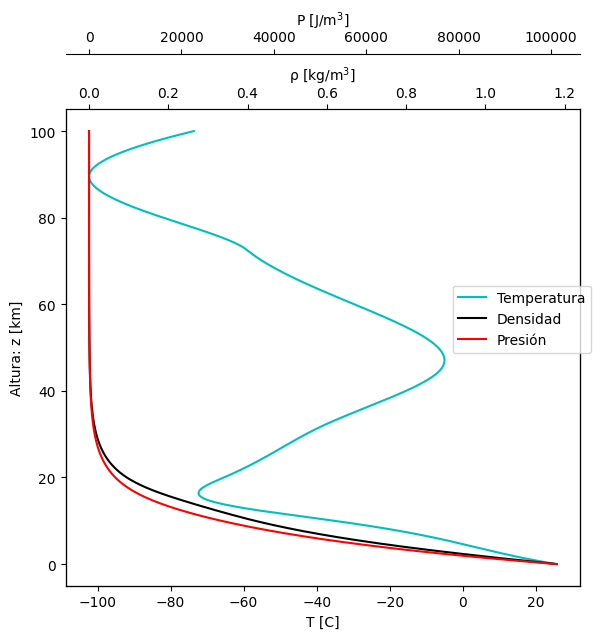

In [ ]:
fig, ax = plt.subplots(figsize=(6,6.5))

ax.plot(Ts_emp-273.15, zs/1e3, 'c', label='Temperatura')
ax.set_xlabel("T [C]")
ax.set_ylabel("Altura: z [km]")

axd = ax.twiny()   # Compartimos el gráfico
axd.plot(rhos_emp, zs/1e3, 'k', label='Densidad')
axd.set_xlabel("ρ [kg/m$^3$]")

axp = ax.twiny()
axp.plot(ps_emp, zs/1e3, 'r', label='Presión')
axp.set_xlabel("P [J/m$^3$]")

# Posicionamiento del eje de presión para evitar la superposición
axp.spines['top'].set_position(('outward', 40))

# Decoración
#ax.margins(0.01,0)
fig.legend(['Temperatura', 'Densidad', 'Presión'], loc='right')

#ax.set_ylim(0,hmax/1e3)
fig.tight_layout()

## Punto 3

Llamamos tropopausa a la altura en la atmósfera en la que la temperatura deja de disminuir con la altura. Encuentre la altura de la **tropopausa**. A la capa de la atmósfera debajo de esa altura se la llama la **tropósfera**. Investiga otras capas de la atmósfera hasta 100 km e identificalas en los gráficos en 2. Haz un gráfico de temperatura como función de la altura e identifica en ese gráfico los límites de cada capa y el nombre de las capas.


### Capas de la atmósfera hasta 100 km

1. **Tropósfera:** Capa sobre la superficie terrestre que alcanza una altura media de entre 18 y 20 km. En esta el aire es calentado por el calor emitido por la superficie, lo cual hace que la temperatura máxima del aire se encuentre en la superficie y disminuya con la altura. La altura hasta la que llega es donde se ubica la tropopausa.


2. **Estratósfera:** Se extiende desde la tropopausa hasta una altura media de 50 a 55 km, altitud en la que se encuentra la estratopausa, que es el lugar en donde la temperatura alcanza su máximo y comienza a disminuir.

  En esta capa se ubica la capa de Ozono y gracias a que absorbe la radiación ultravioleta emitada por el Sol, la temperatura en esta capa atmosférica aumenta con la altura.


3. **Mesósfera:** Capa en la cual la temperatura desciende con la altura debido a la disminución de calentamiento solar y al enfriamiento por emisión de CO$_2$. Se extiende desde la estratopausa hasta la mesopausa a una altura media de 80 a 90 km, lugar en el cual la temperatura es mínima.


4. **Termósfera:** Se sigue por encima de la mesopausa hasta alcanzar una altura media de entre 500 y 1000 km. La temperatura allí aumenta debido a la absorción de radiación solar altamente energética, por lo tanto, su comportamiento depende de la actividad solar.


Fuente: https://en.wikipedia.org/wiki/Atmosphere_of_Earth#Temperature

In [ ]:
# ============================ Capas de la atmósfera ===========================
# Tropopausa
T_trop = min(Ts_emp[zs < 20*1e3])   # [K]- 273.15
z_trop = zs[Ts_emp == T_trop]

print('=========== LÍMITE DE LA TROPÓSFERA ===========')
print('Altura de la tropopausa: %.3lf  [km]' %(z_trop*1e-3))
print('Temperatura en la tropopausa: %.3lf [C]' %(T_trop - 273.15))

# Estratopausa
Tb = Ts_emp[zs < 60*1e3]
zsb = zs[zs < 60*1e3]
Tb = Tb[zsb > 40*1e3]
T_est = max(Tb)              # [K]
z_est = zs[Ts_emp == T_est]  # [m]

print('\n=========== LÍMITE DE LA ESTRATÓSFERA ===========')
print('Altura de la estratopausa: %.3lf  [km]' %(z_est*1e-3))
print('Temperatura en la estratopausa: %.3lf [C]' %(T_est - 273.15))

# Mesopausa
T_mes = min(Ts_emp)
z_mes = zs[Ts_emp == T_mes]

print('\n=========== LÍMITE DE LA MESÓSFERA ===========')
print('Altura de la estratopausa: %.3lf  [km]' %(z_mes*1e-3))
print('Temperatura en la estratopausa: %.3lf [C]' %(T_mes - 273.15))

=========== LÍMITE DE LA TROPÓSFERA ===========
Altura de la tropopausa: 16.400  [km]
Temperatura en la tropopausa: -72.335 [C]

=========== LÍMITE DE LA ESTRATÓSFERA ===========
Altura de la estratopausa: 47.050  [km]
Temperatura en la estratopausa: -5.006 [C]

=========== LÍMITE DE LA MESÓSFERA ===========
Altura de la estratopausa: 89.500  [km]
Temperatura en la estratopausa: -102.328 [C]


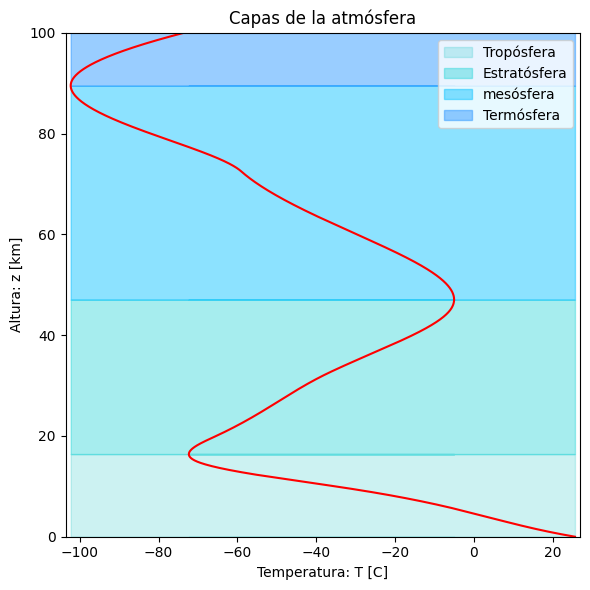

In [ ]:
fig = plt.figure(figsize=(6,6))
plt.title('Capas de la atmósfera')

plt.plot(Ts_emp-273.15, zs/1e3, 'r')

iT_min = np.where(Ts_emp == min(Ts_emp))[0][0]
Ts_fill = Ts_emp[0:iT_min]
plt.fill_between(Ts_fill-273.15, 0, z_trop*1e-3, color='c',alpha=0.2, label='Tropósfera')
plt.fill_between(Ts_fill-273.15, z_trop*1e-3, z_est*1e-3, color='darkturquoise',alpha=0.35, label='Estratósfera')
plt.fill_between(Ts_fill-273.15, z_est*1e-3, z_mes*1e-3, color='deepskyblue',alpha=0.45, label='mesósfera')
plt.fill_between(Ts_fill-273.15, z_mes*1e-3, max(zs)*1e-3, color='dodgerblue',alpha=0.45, label='Termósfera')

plt.legend()
plt.xlabel("Temperatura: T [C]")
plt.ylabel("Altura: z [km]")
plt.margins(0.01,0)
fig.tight_layout()

## Punto 4

Haga un ajuste de la densidad atmosférica empírica como función de la altura en la tropósfera, usando el modelo isotérmico. Determine, por tanto, el valor de $h_0$ y $\rho_0$ que mejor se ajustan al perfil de densidad empírico.

\
**Modelo de atmósfera isotérmica:**

Densidad:
$$\rho(z) = \rho_0 e^{-z/h_0}$$

In [ ]:
from scipy.optimize import curve_fit

""" Se determinan los parámetros rho0 y h0 de la densidad atmosférica isotermica
    a partir de un ajuste de esta densidad con los datos de densidad atmosférica empírica
    que ya se determinaron en los puntos anteriores.
"""

# Densidad isotérmica
rho_iso = lambda z, rho0, h0: rho0*np.exp(-z/h0)   # rho0 y h0 son los parámetros a ajustar

""" Alturas y densidades sólo en la tropósfera """
ind_trop = np.where(zs == z_trop)[0][0]     # índice del arreglo de datos para la tropopausa
zs_trop = zs[0:ind_trop+1]
rhos_emp_trop = rhos_emp[0:ind_trop+1]

# popt: Valores óptimos de los parámetros
# popv: covarianza de popt
popt, popv = curve_fit(rho_iso, zs_trop*1e-3, rhos_emp_trop)
rho0_iso, h0_iso = popt    # [kg/m^3], [km]
h0_iso = h0_iso*1e3        # [m] - Escala vertical incompresible

rhos_iso = rho_iso(zs_trop, rho0_iso, h0_iso)

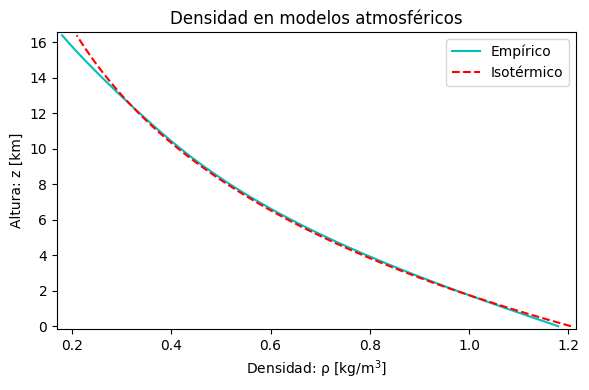

In [ ]:
# Gráfico comparativo
fig = plt.figure(figsize=(6,4))

plt.title('Densidad en modelos atmosféricos')
plt.plot(rhos_emp_trop, zs_trop*1e-3, 'c', label='Empírico')
plt.plot(rhos_iso, zs_trop*1e-3, 'r--', label='Isotérmico')

plt.xlabel('Densidad: ρ [kg/m$^3$]')
plt.ylabel('Altura: z [km]')
plt.margins(0.01,0.01)
plt.legend()
fig.tight_layout()

## Punto 5

Con ese valor de $\rho_0$ y $h_0$ grafique la presión esperada según el modelo isotérmico. Para ello use el valor de $p_0$ que se sigue de la definición $h_0 = p_0/(\rho_0 g_0)$ y por otro lado la presión superficial empírica. Compare ambas curvas con la curva de presión empírica.

\
**Presión según el modelo de atmósfera isotérmica:**

$$p(z) = p_0 e^{-z/h_0}$$


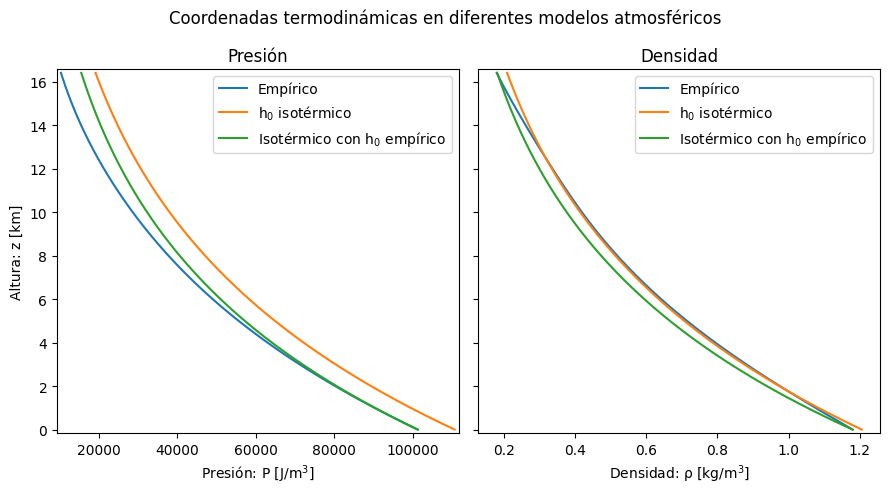

In [ ]:
g0 = 9.8066    # [m/s^2] - Aceleración de la gravedad

# Modelo isotérmico
p0_iso = h0_iso*rho0_iso*g0   # Presión en la superficie
ps_iso = p0_iso*np.exp(-zs_trop/h0_iso)

# Modelo isotérmico con h0 empírico
p0_emp = ps_emp[0]    # Presión en la superficie - modelo empírico
h0_emp = p0_emp/(rhos_emp[0]*g0)

# Coordenadas isotérmicas usando p0, rho0 y h0 del modelo empírico
ps_iso_e = p0_emp*np.exp(-zs_trop/h0_emp)
rho_iso_e = rho_iso(zs_trop, rhos_emp[0], h0_emp)

# ================== Gráficos ==================
fig, (axp, axrho) = plt.subplots(1,2, sharey=True)
fig.set_size_inches(9,5)
fig.suptitle('Coordenadas termodinámicas en diferentes modelos atmosféricos')

axp.set_title('Presión')
axp.plot(ps_emp[0:ind_trop+1], zs_trop*1e-3, label='Empírico')
axp.plot(ps_iso, zs_trop*1e-3, label='h$_0$ isotérmico')
axp.plot(ps_iso_e, zs_trop*1e-3, label='Isotérmico con h$_0$ empírico')

axrho.set_title('Densidad')
axrho.plot(rhos_emp_trop, zs_trop*1e-3, label='Empírico')
axrho.plot(rhos_iso, zs_trop*1e-3, label='h$_0$ isotérmico')
axrho.plot(rho_iso_e, zs_trop*1e-3, label='Isotérmico con h$_0$ empírico')

axp.set_xlabel('Presión: P [J/m$^3$]')
axrho.set_xlabel('Densidad: ρ [kg/m$^3$]')
axp.set_ylabel('Altura: z [km]')
axp.legend()
axrho.legend()
axp.margins(0.01, 0.01)

fig.tight_layout()

## Punto 6

Repita el procedimiento anterior pero con el modelo homentrópico. El ajuste a la curva de densidad le debe devolver el valor de 3 parámetros, $\rho_0$, $h_2$ y $\gamma$. Deduzca con estos valores un nuevo valor para $h_0$ y compárelo con el que obtuvo en 4. Con estos parámetros haga como hizo en 5 curvas de presión como función de la altura y compare con el modelo empírico.

\
**Densidad y presión según el modelo homentrópico:**

$$\rho(z) = \rho_0(1 - z/h_2)^{\frac{1}{\gamma-1}}$$

$$P(z) = P_0(1 - z/h_2)^{\frac{1}{\gamma-1}}$$


Donde:
* $h_2$ es la escala de altura.

* $\gamma$ el índice adiabático.

A partir de los parámetros anteriores es posible determinar la escala vertical incompresible, $h_0$, para el modelo homentrópico con la relación de escalas:

$$h_2 = \frac{\gamma}{\gamma-1}h_0 = \frac{c_p T_0}{g_0}$$

\
**Presión:**



Modelo empírico 	 Escala vertical incompresible: h0 = 8.748 [km]
Modelo isotérmico 	 Escala vertical incompresible: h0 = 9.357 [km]
Modelo homentrópico 	 Escala vertical incompresible: h0 = 8.953 [km] 



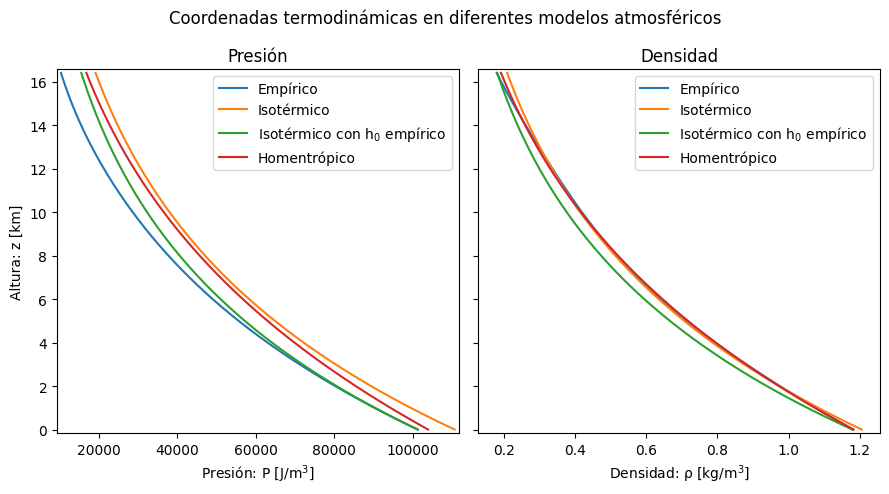

In [ ]:
# Densidad homentrópica
rho_hom = lambda z, rho0, h2, gamma: rho0*(1-z/h2)**(1/(gamma-1))

""" Nota: En esta ocasión es necesario asignar valores supuestos iniciales para los
    parámetros, pues, como curve_fit supone inicialmente que estos valores son 1,
    gamma=1 produce una indeterminación en la función de densidad homentrópica """
# Valores iniciales para los parámetros
c0 = [rhos_emp[0], 30, 6/5]

popt, popv = curve_fit(rho_hom, zs_trop*1e-3, rhos_emp_trop, c0)

rho0_hom, h2_hom, gamma_hom = popt    # [kg/m^3], [km], [adimensional]
h2_hom = h2_hom*1e3                   # [m] - Escala de altura

h0_hom = (gamma_hom-1)*h2_hom/gamma_hom   # [m] - Escala vertical incompresible homentrópica

print('Modelo empírico \t Escala vertical incompresible: h0 = %.3lf [km]' %(h0_emp*1e-3))
print('Modelo isotérmico \t Escala vertical incompresible: h0 = %.3lf [km]' %(h0_iso*1e-3))
print('Modelo homentrópico \t Escala vertical incompresible: h0 = %.3lf [km] \n' %(h0_hom*1e-3))

# ====================== Curvas de presión y densidad ======================
p0_hom = h0_hom*rho0_hom*g0
ps_hom = p0_hom*(1-zs_trop/h2_hom)**(1/(gamma_hom-1))
rhos_hom = rho_hom(zs_trop, rho0_hom, h2_hom, gamma_hom)

# Gráficos
fig, (axp, axrho) = plt.subplots(1,2, sharey=True)
fig.set_size_inches(9,5)
fig.suptitle('Coordenadas termodinámicas en diferentes modelos atmosféricos')

axp.set_title('Presión')
axp.plot(ps_emp[0:ind_trop+1], zs_trop*1e-3, label='Empírico')
axp.plot(ps_iso, zs_trop*1e-3, label='Isotérmico')
axp.plot(ps_iso_e, zs_trop*1e-3, label='Isotérmico con h$_0$ empírico')
axp.plot(ps_hom, zs_trop*1e-3, label='Homentrópico')

axrho.set_title('Densidad')
axrho.plot(rhos_emp_trop, zs_trop*1e-3, label='Empírico')
axrho.plot(rhos_iso, zs_trop*1e-3, label='Isotérmico')
axrho.plot(rho_iso_e, zs_trop*1e-3, label='Isotérmico con h$_0$ empírico')
axrho.plot(rhos_hom, zs_trop*1e-3, label='Homentrópico')

axp.set_xlabel('Presión: P [J/m$^3$]')
axrho.set_xlabel('Densidad: ρ [kg/m$^3$]')
axp.set_ylabel('Altura: z [km]')
axp.legend()
axrho.legend()
axp.margins(0.01, 0.01)

fig.tight_layout()

## Punto 7

¿Dependerá el valor de $h_0$ del lugar en la Tierra en el que estás el mismo día de tu nacimiento?. Repita el procedimiento 6 para otras 3 ciudades (aquellas a las que te soñarías viajar), ojalá de latitudes geográficas diversas, es decir, cerca al ecuador, pero también en latitudes altas, al norte o al Sur ¿qué observas? ¿cómo lo interpretas?


In [ ]:
def empiric_model(fecha, lat, lon, hmax):
  zs = np.arange(0,hmax*1e3+50, 50)   # [m] - Altura

  # ds = msise_4d(datetime(Y,M,D, 12,0,0), zs/1e3, [lat], [lon])
  ds = msise_4d(fecha, zs/1e3, [lat], [lon])

  rhos_emp = np.array(ds["rho"]).flatten()*1e3  # [kg/m^3]
  Ts_emp = np.array(ds["Talt"]).flatten()       # [K]

  # ============ Masa molar total ============
  elms = ['He', 'O', 'N2', 'O2', 'Ar', 'H', 'N']
  Ms_mol = np.array([2*4.0026, 15.999, 2*14.007, 2*15.999, 39.948, 1.008, 14.007])   # [g/mol]

  ns_aire = np.zeros(len(zs))
  Mmols = np.zeros(len(zs))

  for i in range(len(elms)):
    ns_e = np.array(ds[elms[i]]).flatten()
    Mmols += ns_e*Ms_mol[i]
    ns_aire += ns_e

  Mmols = Mmols/ns_aire*1e-3    # [kg/mol]

  # ============ Presión empírica ============
  ps_emp = rhos_emp*R*Ts_emp/Mmols

  # Tropopausa
  T_trop = min(Ts_emp[zs < 20*1e3])   # [K]- 273.15
  z_trop = zs[Ts_emp == T_trop]

  # El índice permite acotar todas las coordenadas termodinámicas hasta la tropopausa
  ind_trop = np.where(zs == z_trop)[0][0]

  return rhos_emp, Ts_emp, ps_emp, zs, ind_trop
#

""" ############# Modelo isotérmico ############# """
def iso_model(zs, rhos):
  rho_iso = lambda z, rho0, h0: rho0*np.exp(-z/h0)

  popt, popv = curve_fit(rho_iso, zs*1e-3, rhos)
  rho0_iso, h0_iso = popt    # [kg/m^3], [km]
  h0_iso = h0_iso*1e3        # [m] - Escala vertical incompresible

  rhos_iso = rho_iso(zs, rho0_iso, h0_iso)   # Densidades

  p0_iso = h0_iso*rho0_iso*g0   # Presión en la superficie
  ps_iso = p0_iso*np.exp(-zs/h0_iso)

  return rhos_iso, ps_iso, h0_iso

""" ############# Modelo homentrópico ############# """
def hom_model(zs, rhos):
  rho_hom = lambda z, rho0, h2, gamma: rho0*(1-z/h2)**(1/(gamma-1))

  # Valores iniciales para los parámetros
  c0 = [1, 60, 7/5]

  popt, popv = curve_fit(rho_hom, zs*1e-3, rhos, c0)
  rho0_hom, h2, gamma_hom = popt    # [kg/m^3], [km], [adimensional]
  h2 = h2*1e3                   # [m] - Escala de altura

  h0_hom = (gamma_hom-1)*h2/gamma_hom

  rhos_hom = rho_hom(zs, rho0_hom, h2, gamma_hom)   # Densidades

  p0_hom = h0_hom*rho0_hom*g0
  ps_hom = p0_hom*(1-zs/h2)**(1/(gamma_hom-1))

  return rhos_hom, ps_hom, h0_hom

In [ ]:
lats = np.linspace(-90, 90, 20)
lon = -75.5388
fecha = datetime(1999,9,14,12,0,0)
hmax = 40            # [km] - altura máxima

h0s = np.zeros([len(lats), 3])

for i in range(len(lats)):
  rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(fecha, lats[i], lon, hmax)      # >>>>>>

  h0_emp = ps_emp[0]/(rhos_emp[0]*g0)    # [m] - Escala vertical incompresible

  zs_trop = zs[0:ind_trop+1]    # Alturas en la tropósfera
  rhos_emp_trop = rhos_emp[0:ind_trop+1]

  rhos_iso, ps_iso, h0_iso = iso_model(zs_trop, rhos_emp_trop)
  rhos_hom, ps_hom, h0_hom = hom_model(zs_trop, rhos_emp_trop)

  h0s[i] = h0_emp, h0_iso, h0_hom

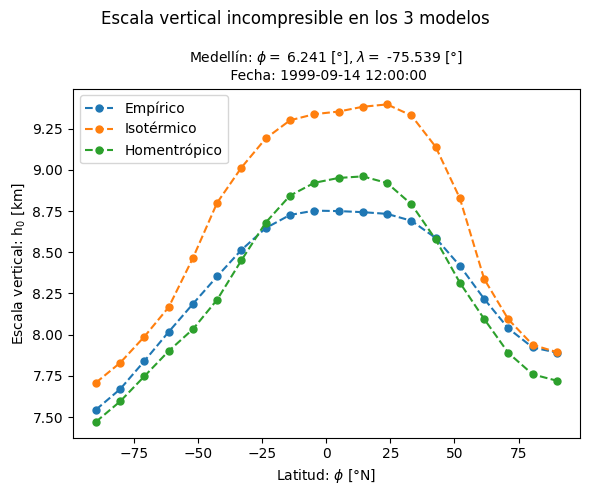

In [ ]:
fig = plt.figure(figsize=(6,5))
fig.suptitle('Escala vertical incompresible en los 3 modelos', fontsize=12)
plt.title(f'Medellín: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°] \n Fecha: {fecha}' %(lat,lon), fontsize=10)

plt.plot(lats, h0s[:,0]*1e-3, 'o--', label='Empírico', markersize=5)
plt.plot(lats, h0s[:,1]*1e-3, 'o--', label='Isotérmico', markersize=5)
plt.plot(lats, h0s[:,2]*1e-3, 'o--', label='Homentrópico', markersize=5)

plt.legend()
plt.xlabel('Latitud: $\phi$ [°N]')
plt.ylabel('Escala vertical: h$_0$ [km]')
fig.tight_layout()

**Observaciones:**

* Del gráfico podemos notar que la escala vertical incompresible no es constante para cualquier latitud geográfica. Vemos que se comporta como una parábola invertida donde es más pronunciada cuando nos ubicamos en regiones cercanas al ecuador y más pequeñas cuando nos acercamos a los polos.

  Esto significa que la atmósfera en el ecuador se expande más, lo cual puede ser debido al efecto de la rotación de la Tierra es máxima en el ecuador, lo que hace las partículas de la atmósfera se muevan con una velocidad más alta que en latitudes más altas; y al hecho de que la radiación solar incide más directamente sobre el ecuador.

* Notamos también que el modelo atmosférico que más se acerca al comportamiento empírico (aproximadamente real) es el homentrópico.

## Punto 8

¿Dependerá el valor de $h_0$ de la fecha del año?. Toma 2 ciudades, una cerca al ecuador y otra en una latitud alta (ojalá por encima de los 45 grados de latitud norte o sur) y determina $h_0$ en verano y en invierno (siempre a la misma hora, el medio día) ¿qué observas? ¿cómo lo interpretas?

In [ ]:
lat = 6.2408606               # Medellín

# Ciudad de latitud alta
lat2, lon2 = 46.20167, 6.146944    # Ginebra

verano = datetime(2022,6,13,12,0,0)     # Fecha de verano
invierno = datetime(2022,12,10,12,0,0)  # Fecha de invierno

""" ########### Medellín ########### """
# Verano
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(verano, lat, lon, hmax)
zs_trop = zs[0:ind_trop+1]
rhos_emp_trop = rhos_emp[0:ind_trop+1]
rhos_hom, ps_hom, h0_hom = hom_model(zs_trop, rhos_emp_trop)

h0_Mv = ps_emp[0]/(rhos_emp[0]*g0)
h0Mv_hom = h0_hom

# Invierno
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(invierno, lat, lon, hmax)
zs_trop = zs[0:ind_trop+1]
rhos_emp_trop = rhos_emp[0:ind_trop+1]
rhos_hom, ps_hom, h0_hom = hom_model(zs_trop, rhos_emp_trop)

h0_Miv = ps_emp[0]/(rhos_emp[0]*g0)
h0Miv_hom = h0_hom

""" ########### Ginebra ########### """
# Verano
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(verano, lat2, lon2, hmax)
zs_trop = zs[0:ind_trop+1]
rhos_emp_trop = rhos_emp[0:ind_trop+1]
rhos_hom, ps_hom, h0_hom = hom_model(zs_trop, rhos_emp_trop)

h0_Gv = ps_emp[0]/(rhos_emp[0]*g0)
h0Gv_hom = h0_hom

# Invierno
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(invierno, lat2, lon2, hmax)
zs_trop = zs[0:ind_trop+1]
rhos_emp_trop = rhos_emp[0:ind_trop+1]
rhos_hom, ps_hom, h0_hom = hom_model(zs_trop, rhos_emp_trop)

h0_Giv = ps_emp[0]/(rhos_emp[0]*g0)
h0Giv_hom = h0_hom

In [ ]:
print('======= ESCALA VERTICAL INCOMPRESIBLE: h0 [km] =======\n')

print('### MODELO EMPÍRICO ###')
print('\t\t Verano \t Invierno - 12 del medio día')
print('Ciudad    \t 13-6-2020 \t 10-12-2020')
print('------------------------------------------------')
print('Medellín: \t %.3lf \t\t %.3lf' %(h0_Mv*1e-3, h0_Gv*1e-3))
print('Ginebra:  \t %.3lf \t\t %.3lf' %(h0_Miv*1e-3, h0_Giv*1e-3))

print('\n\n### MODELO HOMENTRÓPICO ###')
print('\t\t Verano \t Invierno - 12 del medio día')
print('Ciudad    \t 13-6-2020 \t 10-12-2020')
print('------------------------------------------------')
print('Medellín: \t %.3lf \t\t %.3lf' %(h0Mv_hom*1e-3, h0Gv_hom*1e-3))
print('Ginebra:  \t %.3lf \t\t %.3lf' %(h0Miv_hom*1e-3, h0Giv_hom*1e-3))

======= ESCALA VERTICAL INCOMPRESIBLE: h0 [km] =======

### MODELO EMPÍRICO ###
		 Verano 	 Invierno - 12 del medio día
Ciudad    	 13-6-2020 	 10-12-2020
------------------------------------------------
Medellín: 	 8.757 		 8.482
Ginebra:  	 8.752 		 8.299


### MODELO HOMENTRÓPICO ###
		 Verano 	 Invierno - 12 del medio día
Ciudad    	 13-6-2020 	 10-12-2020
------------------------------------------------
Medellín: 	 9.032 		 8.426
Ginebra:  	 9.040 		 8.216


**Observaciones:**

* De los resultados anteriores podemos notar que en el invierno la escala vertical incompresible para ambas ciudades disminuye, esto puede ser debido a que la atmósfera se contrae en estas épocas, de manera que las partículas adquieren una menor energía cinética con la disminución de la temperatura, aumentando así la densidad atmosférica.

* Hay una mayor disminución de $h_0$ de verano a invierno para la ciudad de Ginebra y esto puede ser debido a que en estas latitudes la radiación solar influye menos en ciudades con latitudes altas, y por tanto el efecto de la disminución de temperaturas es más notorio allí.

* Con el modelo homentrópico se lograron los mismos efectos, pero con una mayor variación en la escala vertical en comparación con el modelo empírico.

In [ ]:
""" lat2, lon2 = 46.20167, 6.146944    # Ginebra """

fecha = datetime(2022,1,1,0,0)
dt = timedelta(days = 15)
fechaf = datetime(2022,12,31,12,0,0)

h0s_G = []
h0s_M = []
fechas = []
while fecha <= (fechaf-dt):
  # Ginebra
  rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(fecha, lat2, lon2, hmax)
  h0 = ps_emp[0]/(rhos_emp[0]*g0)
  h0s_G.append(h0)

  # Medellín
  rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(fecha, lat, lon, hmax)
  h0 = ps_emp[0]/(rhos_emp[0]*g0)
  h0s_M.append(h0)

  fechas.append(fecha)
  fecha += dt

#### Estaciones del año

**Invierno:** Desde el solsticio de diciembre hasta el equinoccio de marzo: día 20 y a veces 19

**Primavera:** Desde el equinocio de marzo al solsticio de junio: días 20 o 21

**Verano:** Desde el solsticio de junio hasta el equinoccio de septiembre: día 22 y a veces 23.

**Otoño:** Desde el equinoccio de septiembre hasta el solsticio de diciembre: día 21 a veces 22.

Fuente: https://es.wikipedia.org/wiki/Estaciones_del_año

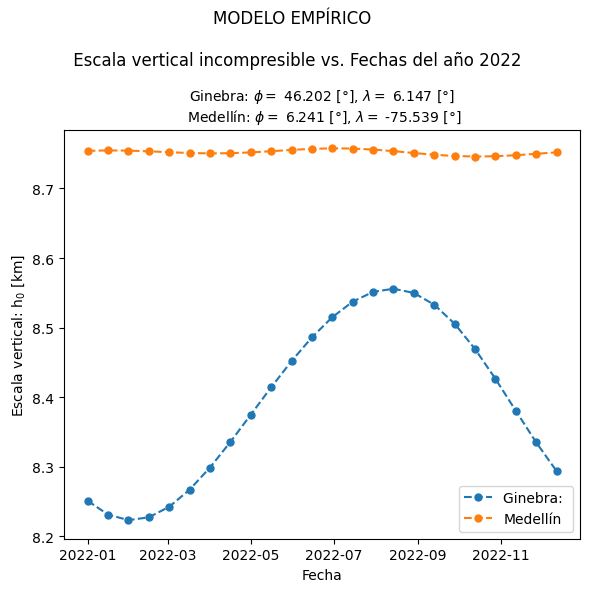

In [ ]:
fig = plt.figure(figsize=(6,6))
fig.suptitle('MODELO EMPÍRICO \n\n Escala vertical incompresible vs. Fechas del año 2022', fontsize=12)

plt.title('Ginebra: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]\n Medellín: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]' %(lat2, lon2, lat, lon), fontsize=10)

h0s_G = np.array(h0s_G)
plt.plot(fechas, h0s_G*1e-3, 'o--', label='Ginebra: ', markersize=5)

h0s_M = np.array(h0s_M)
plt.plot(fechas, h0s_M*1e-3, 'o--', label='Medellín', markersize=5)

# plt.fill_between()

plt.legend()
plt.xlabel('Fecha')
plt.ylabel('Escala vertical: h$_0$ [km]')
fig.tight_layout()

**Observaciones:**

* Del gráfico podemos notar que en Medellín no hay una variación significativa de $h_0$ con la época del año, y esto es debido a que cerca al ecuador la intensidad de radiación solar no cambia significativamente, por lo que los cambios de temperatura que sufre la atmósfera tampoco son muy grandes, a diferencia de las latitudes altas donde las estaciones del año son mucho más pronunciadas.

## Punto 9

¿Dependerá el valor de $h_0$ de la actividad solar?. Toma otras vez las 2 ciudades de 8 y determina el valor de $h_0$ en la fecha del perihelio de un año de mínimo de actividad solar y uno de máximo de actividad solar ¿qué observas?. Repite lo mismo pero comparando la densidad atmosférica a 100 km de altura en ambas fechas ¿hay cambios?

**Fechas de perihelio:**

Fuente: http://astropixels.com/ephemeris/perap2001.html

**Ciclos solares:**

Fuente: https://es.wikipedia.org/wiki/Anexo:Ciclos_solares


In [ ]:
# Fechas de actividad solar mínima y máxima del ciclo solar 24
min_solar = datetime(2008,1,2,12,0,0)
max_solar = datetime(2014,1,4,12,0,0)

""" ########### Medellín ########### """
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(min_solar, lat, lon, hmax)
h0_Mmin = ps_emp[0]/(rhos_emp[0]*g0)

rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(max_solar, lat, lon, hmax)
h0_Mmax = ps_emp[0]/(rhos_emp[0]*g0)


""" ########### Ginebra ########### """
rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(min_solar, lat2, lon2, hmax)
h0_Gmin = ps_emp[0]/(rhos_emp[0]*g0)

rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(max_solar, lat2, lon2, hmax)
h0_Gmax = ps_emp[0]/(rhos_emp[0]*g0)

In [ ]:
print('########## MODELO EMPÍRICO ##########\n')
print('Perihelios \t\t Escala vertical incompresible: h0 [km]')
print('---------------------------------------------------------')
print('Mínimo solar \t\t Medellín \t Ginebra')
print(f'{min_solar} \t %.5lf \t %.5lf' %(h0_Mmin*1e-3, h0_Gmin*1e-3))
print('\nMáximo solar')
print(f'{max_solar} \t %.5lf \t %.5lf' %(h0_Mmax*1e-3, h0_Gmax*1e-3))

########## MODELO EMPÍRICO ##########

Perihelios 		 Escala vertical incompresible: h0 [km]
---------------------------------------------------------
Mínimo solar 		 Medellín 	 Ginebra
2008-01-02 12:00:00 	 8.75418 	 8.24942

Máximo solar
2014-01-04 12:00:00 	 8.75431 	 8.24622


**Observación:**

* Notamos que la escala vertical incompresible en la fecha del perihelio en el mínimo solar se diferencia con el máximo solar sólo entre la tercera (Ginebra) o cuarta (Medellín) cifra decimal.

* En el máximo solar, aumenta la escala para Medellín. En el ecuador la atmósfera está más expandida debido al efecto de rotación terrestre y a que le llega más radiación del Sol, por tanto, la termósfera tiene una menor densidad y mayor temperatura, por tanto, un aumento de radiación penetra más profundamente a las capas inferiores de la atmósfera haciendo que esta se expanda más.

* Caso contrario de ciudades de latitudes altas donde la termósfera tiene mayor densidad y menor temperatura, por lo que esta capa tiene mayor capacidad para observar la radiación solar.


**Nota:** No sé cómo se puede explicar porqué en el máximo solar la atmósfera se contrae, es decir, $h_0$ disminuye.

In [ ]:
""" =============== Ciclo solar 24 =============== """
year_date = np.array([
    [2008, datetime(2008,1,2,12,0,0)],    # Mínimo solar
    [2009, datetime(2009,1,4,12,0,0)],
    [2010, datetime(2010,1,3,12,0,0)],
    [2011, datetime(2011,1,3,12,0,0)],
    [2012, datetime(2012,1,5,12,0,0)],
    [2013, datetime(2013,1,2,12,0,0)],
    [2014, datetime(2014,1,4,12,0,0)],    # Máximo solar
    [2015, datetime(2015,1,4,12,0,0)],
    [2016, datetime(2016,1,2,12,0,0)],
    [2017, datetime(2017,1,4,12,0,0)],
    [2018, datetime(2018,1,3,12,0,0)],
    [2019, datetime(2019,1,3,12,0,0)]
])

h0s_cs24_M = np.zeros(len(year_date))
h0s_cs24_G = np.zeros(len(year_date))
hmax = 100    # [km]
rhos_cs24_M = np.zeros(len(year_date))
rhos_cs24_G = np.zeros(len(year_date))

for i in range(len(year_date)):
  fecha = year_date[i,1]

  # Medellín
  rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(fecha, lat, lon, hmax)
  h0 = ps_emp[0]/(rhos_emp[0]*g0)
  h0s_cs24_M[i] = h0
  rhos_cs24_M[i] = rhos_emp[-1]   # Densidad a 100 km - Termósfera

  # Ginebra
  rhos_emp, Ts_emp, ps_emp, zs, ind_trop = empiric_model(fecha, lat2, lon2, hmax)
  h0 = ps_emp[0]/(rhos_emp[0]*g0)
  h0s_cs24_G[i] = h0
  rhos_cs24_G[i] = rhos_emp[-1]   # Densidad a 100 km - Termósfera

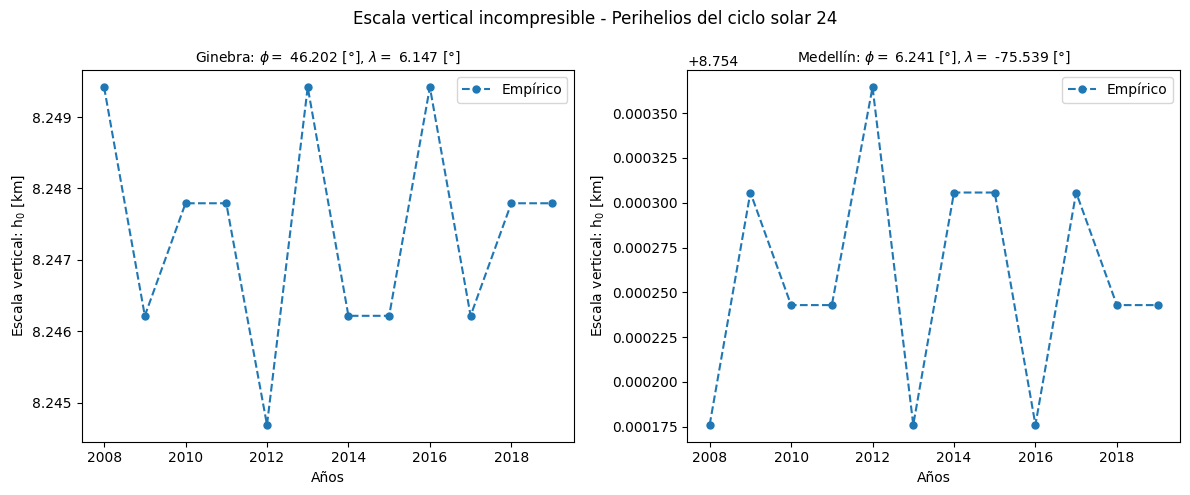

In [ ]:
fig = plt.figure(figsize=(12,5))
fig.suptitle('Escala vertical incompresible - Perihelios del ciclo solar 24', fontsize=12)

# Ginebra ==================
plt.subplot(121)
plt.title('Ginebra: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]' %(lat2, lon2), fontsize=10)

plt.plot(year_date[:,0], h0s_cs24_G*1e-3, 'o--', label='Empírico', markersize=5)

plt.legend()
plt.xlabel('Años')
plt.ylabel('Escala vertical: h$_0$ [km]')

# Medellín ==================
plt.subplot(122)
plt.title('Medellín: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]' %(lat, lon), fontsize=10)

plt.plot(year_date[:,0], h0s_cs24_M*1e-3, 'o--', label='Empírico', markersize=5)

plt.legend()
plt.xlabel('Años')
plt.ylabel('Escala vertical: h$_0$ [km]')

fig.tight_layout()

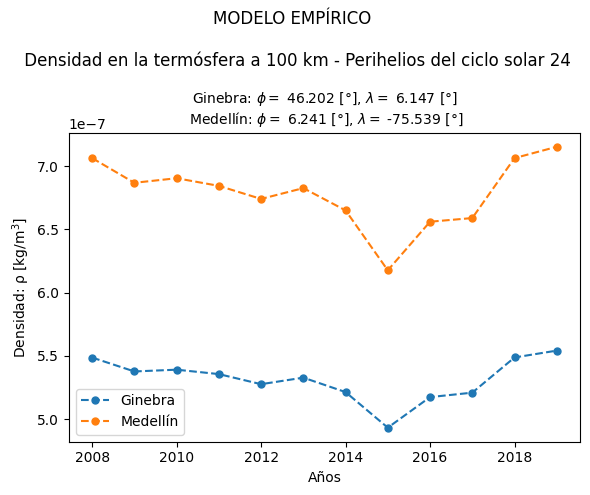

In [ ]:
fig = plt.figure(figsize=(6,5))
fig.suptitle('MODELO EMPÍRICO \n\n Densidad en la termósfera a 100 km - Perihelios del ciclo solar 24', fontsize=12)

#fig.suptitle('MODELO EMPÍRICO \n\n Escala vertical incompresible vs. Fechas del año 2022', fontsize=12)

plt.title('Ginebra: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]\n Medellín: $\phi=$ %.3lf [°], $\lambda=$ %.3lf [°]' %(lat2, lon2, lat, lon), fontsize=10)

plt.plot(year_date[:,0], rhos_cs24_G, 'o--', label='Ginebra', markersize=5)
plt.plot(year_date[:,0], rhos_cs24_M, 'o--', label='Medellín', markersize=5)

plt.legend()
plt.xlabel('Años')
plt.ylabel('Densidad: ρ [kg/m$^3$]')

fig.tight_layout()